## [Image generation](https://platform.openai.com/docs/guides/tools-image-generation) Using OpenAI API

Note: You need to verify your identification to use GTP-5 model

Result image:


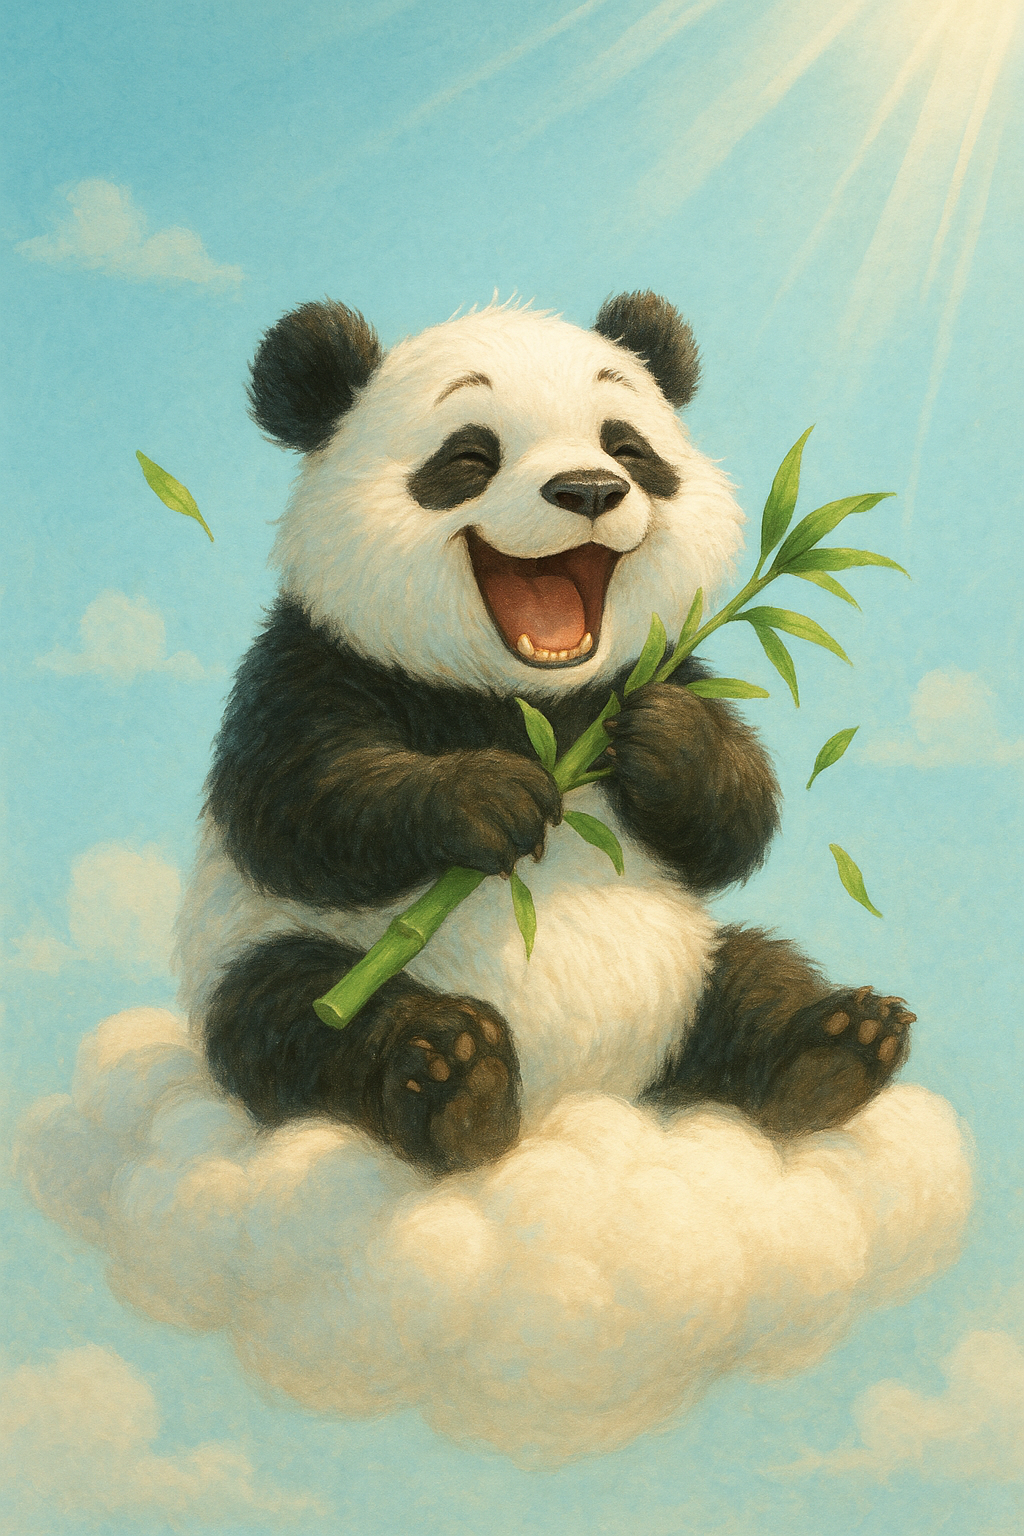

In [1]:
from openai import OpenAI
import base64
from dotenv import load_dotenv
import os
import requests
import datetime
import re
import IPython
from PIL import Image

# define the environment path. it is at the parent folder
env_path ="../.env"
load_dotenv(dotenv_path=env_path, override=True)

api_key = os.getenv("OPENAI_API_KEY")

client = OpenAI() 

response = client.responses.create(
    model="gpt-5",
    input="Laughing panda in the clouds eating bamboo",
    tools=[{"type": "image_generation"}],
)

# Save the image to a file
image_data = [
    output.result
    for output in response.output
    if output.type == "image_generation_call"
]
    
if image_data:
    image_base64 = image_data[0]
    image_path="images/laughing_panda.png"
    with open(image_path, "wb") as f:
        f.write(base64.b64decode(image_base64))
        
        print("Result image:")
        IPython.display.display(Image.open(image_path))        

## Multi-turn editing

Result image:


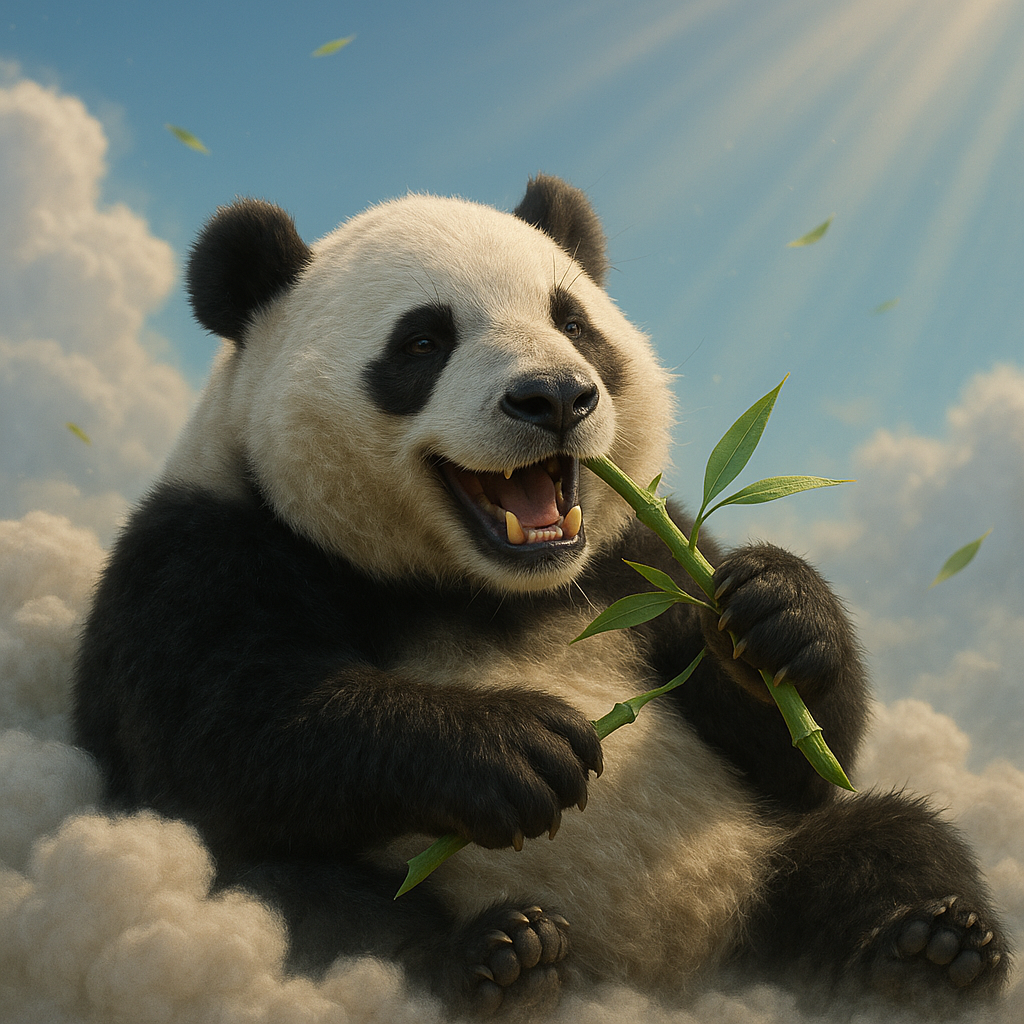

In [2]:
response = client.responses.create(
    model="gpt-5",
    input="Laughing panda in the clouds eating bamboo",
    tools=[{"type": "image_generation"}],
)

image_data = [
    output.result
    for output in response.output
    if output.type == "image_generation_call"
]

if image_data:
    image_base64 = image_data[0]
    image_path="images/laughing_panda_v2.png"
    with open(image_path, "wb") as f:
        f.write(base64.b64decode(image_base64))


# Follow up
response_fwup = client.responses.create(
    model="gpt-5",
    previous_response_id=response.id,
    input="Now make it look realistic",
    tools=[{"type": "image_generation"}],
)

image_data_fwup = [
    output.result
    for output in response_fwup.output
    if output.type == "image_generation_call"
]

if image_data_fwup:
    image_base64 = image_data_fwup[0]
    image_path="images/laughing_panda_realistic.png"
    with open(image_path, "wb") as f:
        f.write(base64.b64decode(image_base64))
        
        print("Result image:")
        IPython.display.display(Image.open(image_path))       